# Uber Analytics – AED (Kaggle) para SCTec - Sesc/SC - Senai/SC | Florianópolis-SC 01-03-2026 BY Leandro Wallauer do Santos

Este notebook realiza uma **Análise Exploratória de Dados (AED)** simples com o dataset **Uber Ride Analytics Dashboard** (Kaggle).

Objetivos:
- Entender padrões de utilização e variações temporais;
- Explorar status (concluídas/canceladas/incompletas);
- Explorar características (tipo de veículo, locais, valor, distância, avaliações);
- Preparar uma base limpa para usos futuros em **IA** (classificação/regressão).


In [1]:
# 1) Imports e configuração
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)


In [2]:
# 2) Leitura do dataset
csv_path = "/kaggle/input/datasets/yashdevladdha/uber-ride-analytics-dashboard/ncr_ride_bookings.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.head()


Shape: (150000, 21)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [3]:
# 3) Setup / Limpeza inicial (blindado para 'Run All')
df_clean = df.copy()

# padroniza nomes (remove espaços)
df_clean.columns = [c.strip() for c in df_clean.columns]

# datetime + variáveis temporais
if "Date" in df_clean.columns and "Time" in df_clean.columns:
    df_clean["datetime"] = pd.to_datetime(
        df_clean["Date"].astype(str) + " " + df_clean["Time"].astype(str),
        errors="coerce"
    )
    df_clean["date"] = df_clean["datetime"].dt.date
    df_clean["hour"] = df_clean["datetime"].dt.hour
    df_clean["day_of_week"] = df_clean["datetime"].dt.day_name()
    df_clean["month"] = df_clean["datetime"].dt.to_period("M").astype(str)

# conversão de numéricas (se existirem)
num_cols = [
    "Avg VTAT", "Avg CTAT", "Cancelled Rides by Customer", "Cancelled Rides by Driver",
    "Incomplete Rides", "Booking Value", "Ride Distance", "Driver Ratings", "Customer Rating"
]
for c in num_cols:
    if c in df_clean.columns:
        df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

# remove duplicatas por Booking ID (se existir)
if "Booking ID" in df_clean.columns:
    before = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=["Booking ID"])
    print("Duplicatas removidas:", before - len(df_clean))

# variável alvo simples p/ classificação (conclusão)
if "Booking Status" in df_clean.columns:
    df_clean["is_completed"] = (df_clean["Booking Status"] == "Completed").astype(int)

print("OK - df_clean:", df_clean.shape)
print("Colunas-chave:", {"datetime": "datetime" in df_clean.columns, "hour": "hour" in df_clean.columns, "is_completed": "is_completed" in df_clean.columns})
df_clean.head()


Duplicatas removidas: 1233
OK - df_clean: (148767, 27)
Colunas-chave: {'datetime': True, 'hour': True, 'is_completed': True}


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,datetime,date,hour,day_of_week,month,is_completed
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,2024-03-23,12,Saturday,2024-03,0
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,2024-11-29,18,Friday,2024-11,0
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,2024-08-23,8,Friday,2024-08,1
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,2024-10-21,17,Monday,2024-10,1
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,2024-09-16,22,Monday,2024-09,1


In [4]:
# 4) Visão geral + valores ausentes + tipos
print("Shape:", df_clean.shape)

print("\nColunas:")
print(df_clean.columns.tolist())

print("\nTipos:")
print(df_clean.dtypes)

print("\n% de valores ausentes (top 15):")
missing = (df_clean.isna().mean() * 100).sort_values(ascending=False)
display(missing.head(15))


Shape: (148767, 27)

Colunas:
['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method', 'datetime', 'date', 'hour', 'day_of_week', 'month', 'is_completed']

Tipos:
Date                                         object
Time                                         object
Booking ID                                   object
Booking Status                               object
Customer ID                                  object
Vehicle Type                                 object
Pickup Location                              object
Drop Location                                object
Avg VTAT                                    float64
Avg CTAT               

Incomplete Rides                     93.999341
Incomplete Rides Reason              93.999341
Cancelled Rides by Customer          93.007858
Reason for cancelling by Customer    93.007858
Cancelled Rides by Driver            81.992646
Driver Cancellation Reason           81.992646
Driver Ratings                       37.991624
Customer Rating                      37.991624
Booking Value                        31.990966
Avg CTAT                             31.990966
Ride Distance                        31.990966
Payment Method                       31.990966
Avg VTAT                              6.991470
Vehicle Type                          0.000000
Pickup Location                       0.000000
dtype: float64

In [5]:
# 5) Distribuição do status e taxa de conclusão
status_counts = df_clean["Booking Status"].value_counts(dropna=False)
display(status_counts)

completed_rate = df_clean["is_completed"].mean()
print(f"Taxa de Completed: {completed_rate:.2%}")


Booking Status
Completed                92248
Cancelled by Driver      26789
Cancelled by Customer    10402
No Driver Found          10401
Incomplete                8927
Name: count, dtype: int64

Taxa de Completed: 62.01%


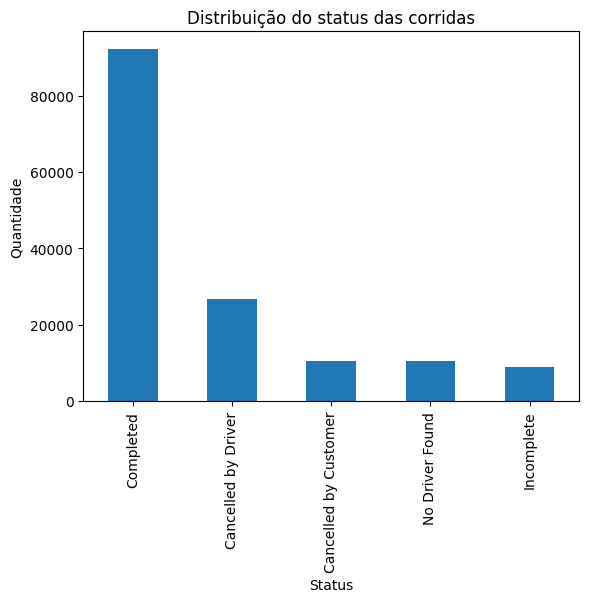

In [6]:
# 6) Gráfico: status das corridas
plt.figure()
df_clean["Booking Status"].value_counts().plot(kind="bar")
plt.title("Distribuição do status das corridas")
plt.xlabel("Status")
plt.ylabel("Quantidade")
plt.show()


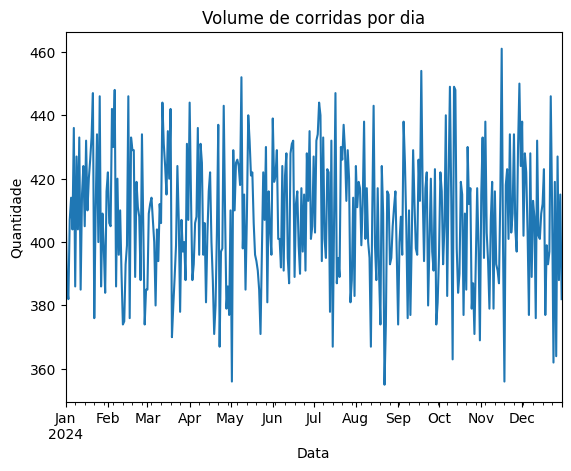

In [7]:
# 7) Volume de corridas por dia (variação temporal)
if "datetime" in df_clean.columns:
    rides_per_day = df_clean.dropna(subset=["datetime"]).groupby(pd.Grouper(key="datetime", freq="D")).size()
    plt.figure()
    rides_per_day.plot()
    plt.title("Volume de corridas por dia")
    plt.xlabel("Data")
    plt.ylabel("Quantidade")
    plt.show()
else:
    print("Coluna datetime não disponível.")


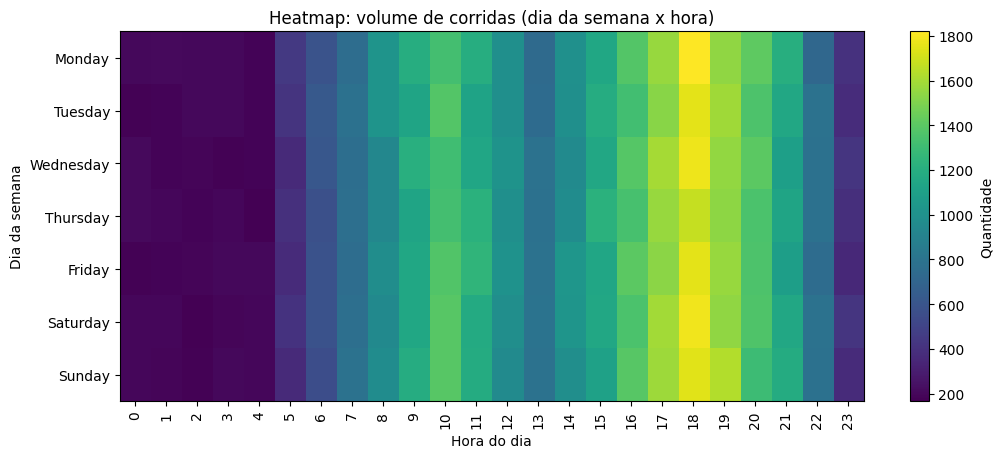

In [8]:
# 8) Heatmap: dia da semana × hora (padrão de demanda)
if "day_of_week" in df_clean.columns and "hour" in df_clean.columns and "Booking ID" in df_clean.columns:
    order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    pivot = (
        df_clean.dropna(subset=["day_of_week","hour"])
        .pivot_table(index="day_of_week", columns="hour", values="Booking ID", aggfunc="count", fill_value=0)
        .reindex(order)
    )

    plt.figure(figsize=(12,4.8))
    plt.imshow(pivot.values, aspect="auto")
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
    plt.title("Heatmap: volume de corridas (dia da semana x hora)")
    plt.xlabel("Hora do dia")
    plt.ylabel("Dia da semana")
    plt.colorbar(label="Quantidade")
    plt.show()
else:
    print("Colunas necessárias não disponíveis (day_of_week/hour/Booking ID).")


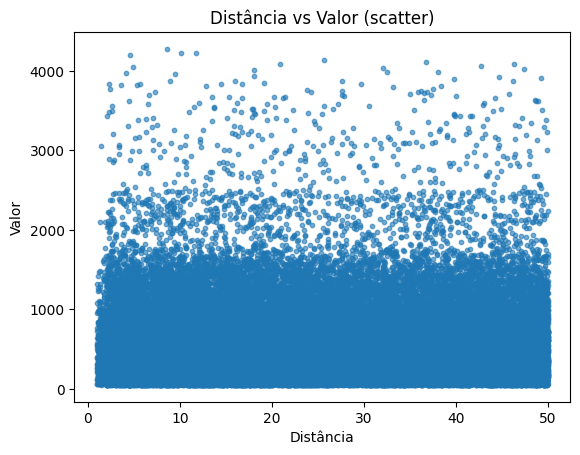

Correlação (Pearson) distância x valor: 0.0051288646833425305


In [9]:
# 9) Distância × Valor (base para regressão)
if "Ride Distance" in df_clean.columns and "Booking Value" in df_clean.columns:
    d = df_clean[["Ride Distance","Booking Value"]].dropna()

    plt.figure()
    plt.scatter(d["Ride Distance"], d["Booking Value"], s=10, alpha=0.6)
    plt.title("Distância vs Valor (scatter)")
    plt.xlabel("Distância")
    plt.ylabel("Valor")
    plt.show()

    print("Correlação (Pearson) distância x valor:", float(d["Ride Distance"].corr(d["Booking Value"])))
else:
    print("Colunas Ride Distance/Booking Value não disponíveis.")


In [10]:
# 10) Taxa total de falha (não concluídas)
fail_rate = 1 - df_clean["is_completed"].mean()
print(f"Taxa total de falha (não concluídas): {fail_rate:.2%}")


Taxa total de falha (não concluídas): 37.99%


Vehicle Type
Go Sedan         0.614465
Auto             0.618654
eBike            0.619621
Premier Sedan    0.621616
Go Mini          0.622682
Bike             0.623757
Uber XL          0.625283
Name: is_completed, dtype: float64

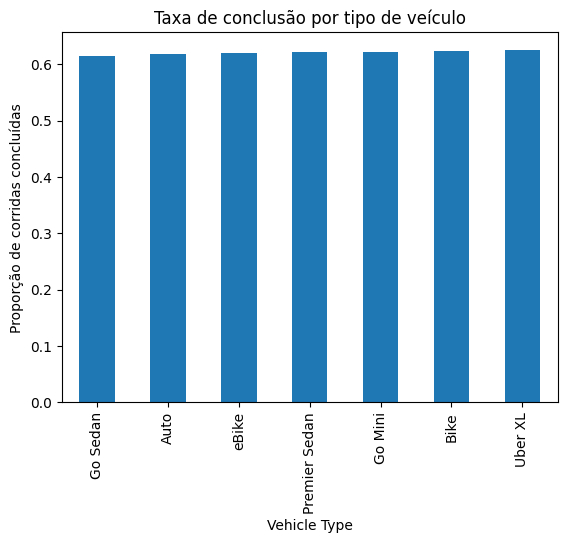

In [11]:
# 11) Taxa de conclusão por tipo de veículo (blindado)
# garante que a coluna existe (evita erro se df_clean for recriado por engano)
if "is_completed" not in df_clean.columns:
    df_clean["is_completed"] = (df_clean["Booking Status"] == "Completed").astype(int)

cancel_by_vehicle = (
    df_clean.groupby("Vehicle Type")["is_completed"]
    .mean()
    .sort_values()
)

display(cancel_by_vehicle)

cancel_by_vehicle.plot(kind='bar')
plt.title("Taxa de conclusão por tipo de veículo")
plt.ylabel("Proporção de corridas concluídas")
plt.show()


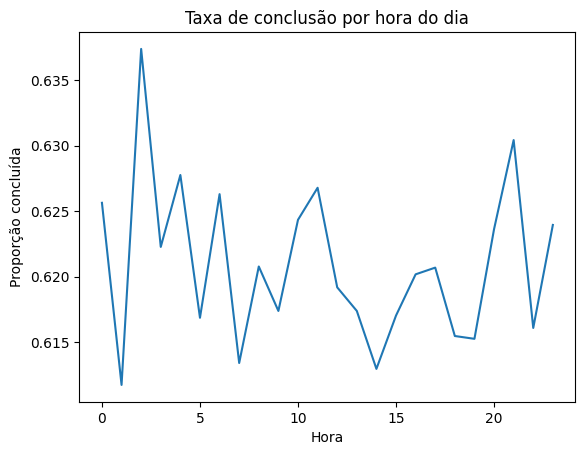

hour
1     0.611730
14    0.612954
7     0.613405
19    0.615251
18    0.615466
22    0.616083
5     0.616860
15    0.617029
9     0.617381
13    0.617382
Name: is_completed, dtype: float64

In [12]:
# 12) Taxa de conclusão por hora
if "hour" in df_clean.columns:
    cancel_by_hour = df_clean.groupby("hour")["is_completed"].mean()

    plt.figure()
    cancel_by_hour.plot()
    plt.title("Taxa de conclusão por hora do dia")
    plt.xlabel("Hora")
    plt.ylabel("Proporção concluída")
    plt.show()

    display(cancel_by_hour.sort_values().head(10))
else:
    print("Coluna hour não disponível.")


In [13]:
# 13) Locais com menor taxa de conclusão (Pickup)
if "Pickup Location" in df_clean.columns:
    pickup_cancel = (
        df_clean.groupby("Pickup Location")["is_completed"]
        .mean()
        .sort_values()
        .head(10)
    )
    display(pickup_cancel)
else:
    print("Coluna Pickup Location não disponível.")


Pickup Location
Vinobapuri              0.547677
Akshardham              0.560479
Chhatarpur              0.581114
Badshahpur              0.581692
Pragati Maidan          0.584430
Vatika Chowk            0.584746
Netaji Subhash Place    0.585662
Faridabad Sector 15     0.587879
IFFCO Chowk             0.589307
Indirapuram             0.591934
Name: is_completed, dtype: float64

Booking Status
Cancelled by Customer           NaN
Cancelled by Driver             NaN
Completed                508.188611
Incomplete               509.340316
No Driver Found                 NaN
Name: Booking Value, dtype: float64

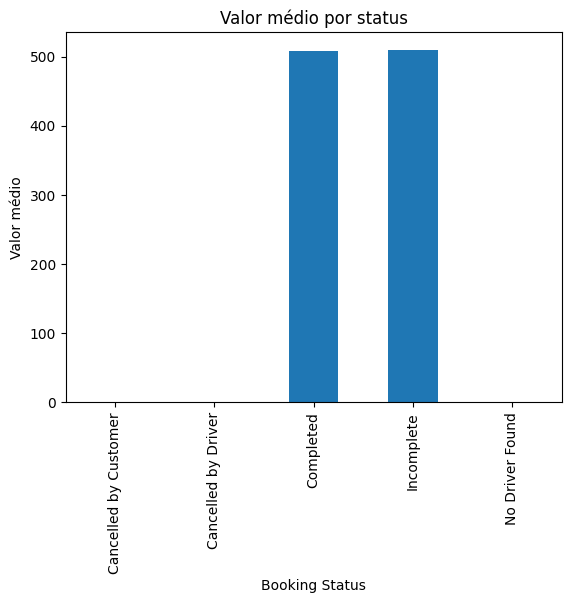

In [14]:
# 14) Valor médio por status
if "Booking Value" in df_clean.columns:
    value_by_status = df_clean.groupby("Booking Status")["Booking Value"].mean()
    display(value_by_status)

    value_by_status.plot(kind="bar")
    plt.title("Valor médio por status")
    plt.ylabel("Valor médio")
    plt.show()
else:
    print("Coluna Booking Value não disponível.")


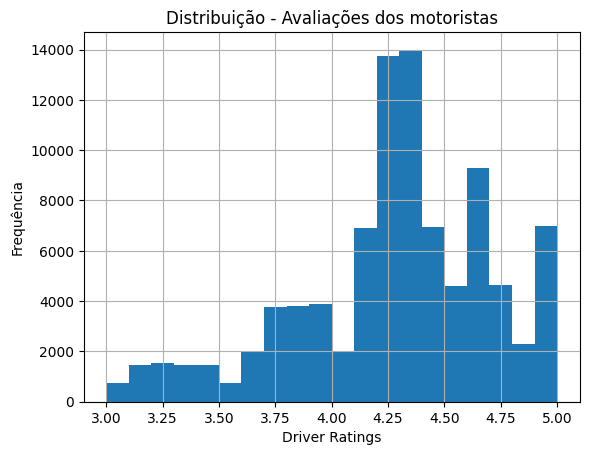

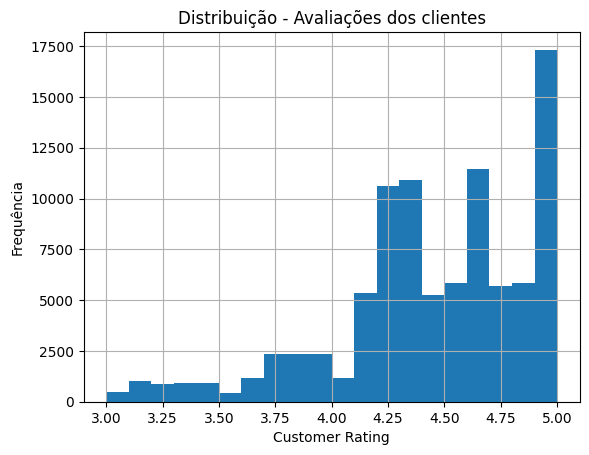

In [15]:
# 15) Distribuição de avaliações (ratings)
for col, title in [("Driver Ratings","Avaliações dos motoristas"), ("Customer Rating","Avaliações dos clientes")]:
    if col in df_clean.columns:
        plt.figure()
        df_clean[col].dropna().hist(bins=20)
        plt.title(f"Distribuição - {title}")
        plt.xlabel(col)
        plt.ylabel("Frequência")
        plt.show()


In [16]:
# 16) Seleção de colunas para modelagem (simples e eficiente)
# Mantemos apenas colunas com potencial de features e alvo(s).
keep_cols = [
    # alvo(s)
    "is_completed", "Booking Value",
    # temporais
    "hour", "day_of_week", "month",
    # categóricas
    "Vehicle Type", "Pickup Location", "Drop Location", "Payment Method",
    # numéricas
    "Ride Distance", "Avg CTAT", "Avg VTAT", "Driver Ratings", "Customer Rating",
]

keep_cols = [c for c in keep_cols if c in df_clean.columns]
df_model = df_clean[keep_cols].copy()

print("df_model shape:", df_model.shape)
display(df_model.head())

print("\n% de nulos (top 10):")
display((df_model.isna().mean()*100).sort_values(ascending=False).head(10))


df_model shape: (148767, 14)


,is_completed,Booking Value,hour,day_of_week,month,Vehicle Type,Pickup Location,Drop Location,Payment Method,Ride Distance,Avg CTAT,Avg VTAT,Driver Ratings,Customer Rating
0,0,NaN,12,Saturday,2024-03,eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN
1,0,237.0,18,Friday,2024-11,Go Sedan,Shastri Nagar,Gurgaon Sector 56,UPI,5.73,14.0,4.9,NaN,NaN
2,1,627.0,8,Friday,2024-08,Auto,Khandsa,Malviya Nagar,Debit Card,13.58,25.8,13.4,4.9,4.9
3,1,416.0,17,Monday,2024-10,Premier Sedan,Central Secretariat,Inderlok,UPI,34.02,28.5,13.1,4.6,5.0
4,1,737.0,22,Monday,2024-09,Bike,Ghitorni Village,Khan Market,UPI,48.21,19.6,5.3,4.1,4.3



% de nulos (top 10):


Customer Rating    37.991624
Driver Ratings     37.991624
Payment Method     31.990966
Ride Distance      31.990966
Booking Value      31.990966
Avg CTAT           31.990966
Avg VTAT            6.991470
Vehicle Type        0.000000
day_of_week         0.000000
hour                0.000000
dtype: float64

In [17]:
# 17) Exportar base limpa (opcional)
# (No Kaggle, o arquivo vai para /kaggle/working/)
out_path = "/kaggle/working/uber_rides_model_ready.csv"
df_model.to_csv(out_path, index=False)
print("Salvo em:", out_path)


Salvo em: /kaggle/working/uber_rides_model_ready.csv
